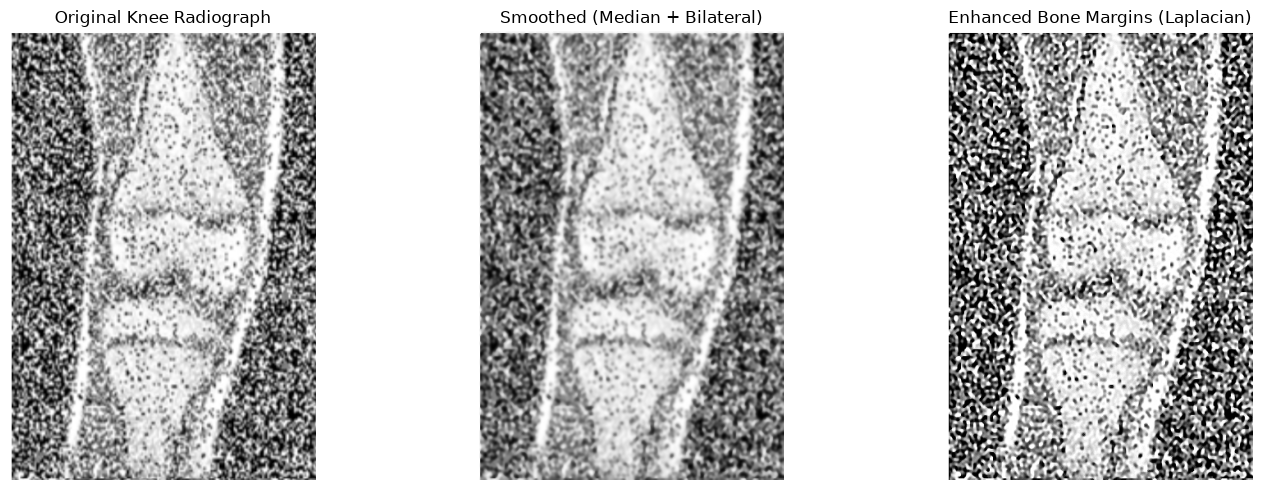

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load medical knee radiograph image
image_path = r"C:\Users\Dev Radia\Pictures\Screenshots\image2.png"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found. Check the path!")
else:
    # 1. Median filtering to suppress high-variance impulse outliers
    median_filtered = cv2.medianBlur(image, 3)

    # 2. Bilateral filtering to smooth bone texture while preserving anatomical boundaries
    # Parameters: d (diameter), sigmaColor (intensity range), sigmaSpace (coordinate space)
    smoothed_bilateral = cv2.bilateralFilter(median_filtered, d=5, sigmaColor=75, sigmaSpace=75)

    # 3. High-boost Laplacian kernel to accentuate structural bone margins and joint space
    sharpening_kernel = np.array([
        [-1, -1, -1],
        [-1,  9, -1],
        [-1, -1, -1]
    ], dtype=np.float32)

    sharpened_image = cv2.filter2D(smoothed_bilateral, -1, sharpening_kernel)

    # 4. Display the processing stages side-by-side
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Knee Radiograph")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(smoothed_bilateral, cmap="gray")
    plt.title("Smoothed (Median + Bilateral)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sharpened_image, cmap="gray")
    plt.title("Enhanced Bone Margins (Laplacian)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()